# EDA — Tumor Survival Prediction

데이터 구조 및 분포 탐색

## 0. 라이브러리 및 경로 설정

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from lifelines import KaplanMeierFitter

sys.path.append(os.path.dirname(os.getcwd()))
from utils import TRAIN_DIR, load_expression, load_survival, find_file

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# 한글 폰트 설정 (set_style 이후에 적용해야 덮어쓰이지 않음)
from matplotlib import font_manager as fm
fm.fontManager.addfont('C:/Windows/Fonts/malgun.ttf')
prop = fm.FontProperties(fname='C:/Windows/Fonts/malgun.ttf')
plt.rc('font', family=prop.get_name())
plt.rc('axes', unicode_minus=False)
print('폰트:', plt.rcParams['font.family'])
print('설정 완료')

폰트: ['Malgun Gothic']
설정 완료


## 1. 데이터 로드

In [2]:
lscc_tumor_prot = load_expression(find_file(TRAIN_DIR, 'LSCC', 'protein_expression_tumor'))
lscc_nat_prot   = load_expression(find_file(TRAIN_DIR, 'LSCC', 'protein_expression_nat'))
luad_tumor_prot = load_expression(find_file(TRAIN_DIR, 'LUAD', 'protein_expression_tumor'))
luad_nat_prot   = load_expression(find_file(TRAIN_DIR, 'LUAD', 'protein_expression_nat'))

lscc_surv = load_survival(find_file(TRAIN_DIR, 'LSCC', 'overall_survival'))
luad_surv = load_survival(find_file(TRAIN_DIR, 'LUAD', 'overall_survival'))

print('로드 완료')

로드 완료


## 2. 기본 데이터 정보

In [3]:
datasets = {
    "LSCC Protein Tumor": lscc_tumor_prot,
    "LSCC Protein NAT":   lscc_nat_prot,
    "LUAD Protein Tumor": luad_tumor_prot,
    "LUAD Protein NAT":   luad_nat_prot,
}

print(f"{'파일':<25} {'샘플':>6} {'유전자':>8} {'NaN%':>8}")
print("-" * 52)
for name, df in datasets.items():
    nan_pct = df.isna().mean().mean() * 100
    print(f"{name:<25} {df.shape[0]:>6} {df.shape[1]:>8} {nan_pct:>7.1f}%")

print()
print(f"{'암종':<6} {'환자':>6} {'Death':>7} {'Survived':>10}")
print("-" * 32)
for name, df in [("LSCC", lscc_surv), ("LUAD", luad_surv)]:
    print(f"{name:<6} {len(df):>6} {int(df.OS_event.sum()):>7} {int((df.OS_event==0).sum()):>10}")

파일                            샘플      유전자     NaN%
----------------------------------------------------
LSCC Protein Tumor            74    12760    15.2%
LSCC Protein NAT              74    12760    15.3%
LUAD Protein Tumor            88    12433    16.9%
LUAD Protein NAT              88    12431    17.0%

암종         환자   Death   Survived
--------------------------------
LSCC       74      18         56
LUAD       88      18         70


## 3. 결측값 분석

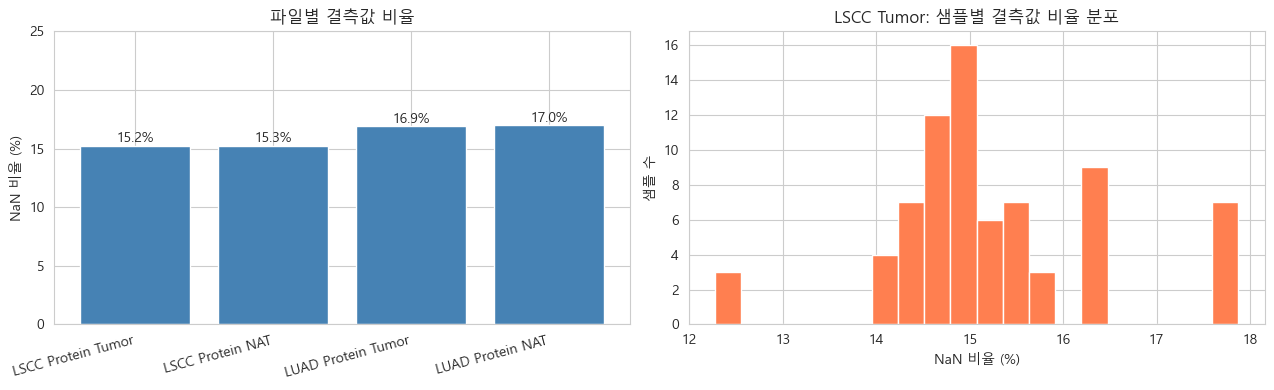

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 파일별 NaN 비율
nan_rates = {k: v.isna().mean().mean() * 100 for k, v in datasets.items()}
bars = axes[0].bar(range(len(nan_rates)), nan_rates.values(), color='steelblue')
axes[0].set_xticks(range(len(nan_rates)))
axes[0].set_xticklabels(nan_rates.keys(), rotation=15, ha='right')
axes[0].set_title('파일별 결측값 비율')
axes[0].set_ylabel('NaN 비율 (%)')
axes[0].set_ylim(0, 25)
for bar, v in zip(bars, nan_rates.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f'{v:.1f}%', ha='center', fontsize=10)

# 샘플별 NaN 비율 분포
sample_nan = lscc_tumor_prot.isna().mean(axis=1) * 100
axes[1].hist(sample_nan, bins=20, color='coral', edgecolor='white')
axes[1].set_title('LSCC Tumor: 샘플별 결측값 비율 분포')
axes[1].set_xlabel('NaN 비율 (%)')
axes[1].set_ylabel('샘플 수')

plt.tight_layout()
plt.show()

## 4. 발현값 분포

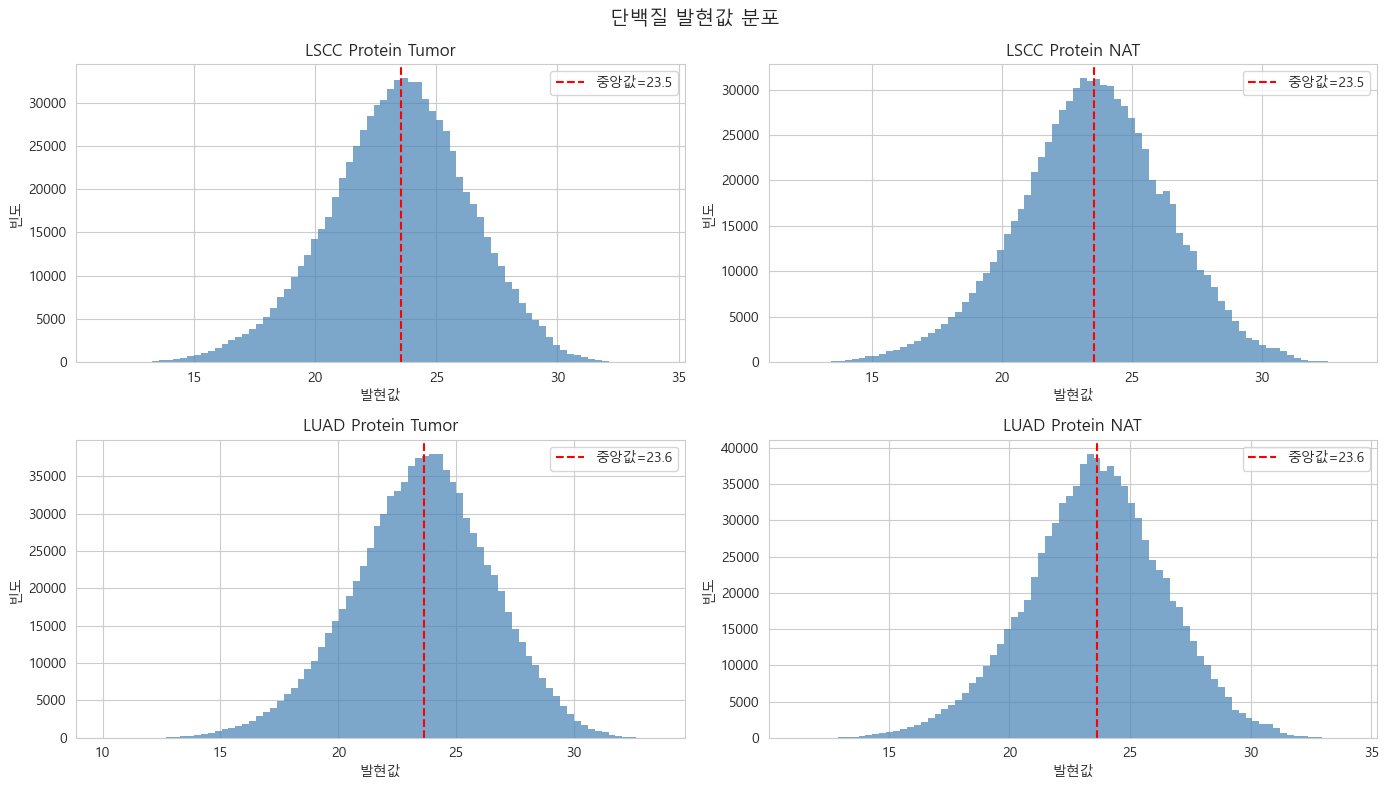

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, df) in zip(axes.flatten(), datasets.items()):
    vals = df.values.flatten()
    vals = vals[~np.isnan(vals)]
    ax.hist(vals, bins=80, color='steelblue', alpha=0.7, edgecolor='none')
    med = np.median(vals)
    ax.axvline(med, color='red', linestyle='--', label=f'중앙값={med:.1f}')
    ax.set_title(name)
    ax.set_xlabel('발현값')
    ax.set_ylabel('빈도')
    ax.legend()

plt.suptitle('단백질 발현값 분포', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Tumor vs NAT 발현 비교

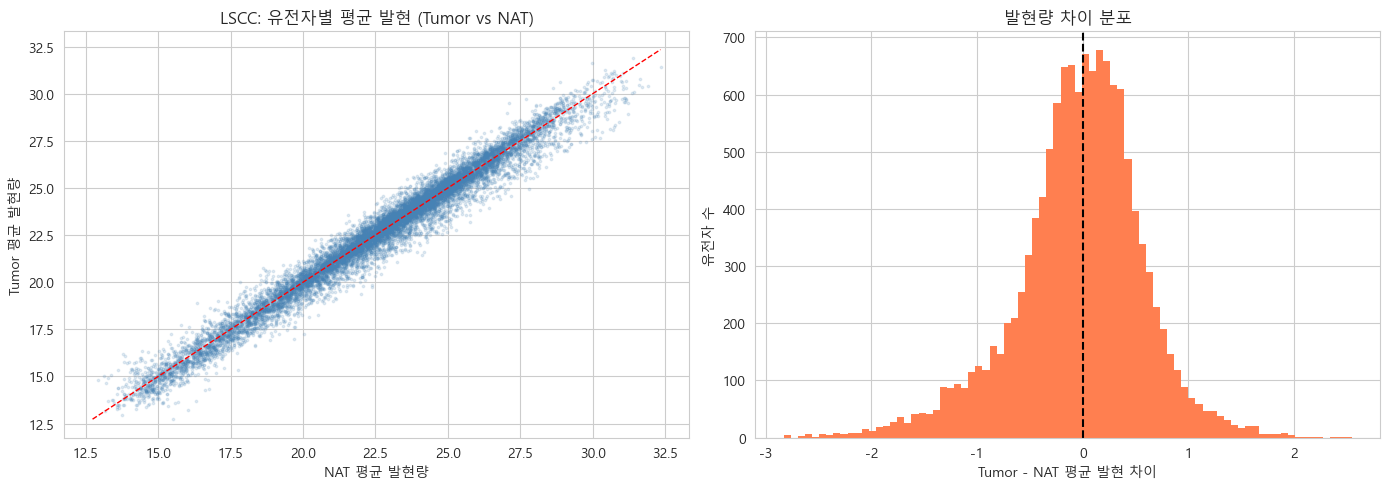

Tumor > NAT 유전자: 6484개
Tumor < NAT 유전자: 6276개


In [6]:
common_genes = lscc_tumor_prot.columns.intersection(lscc_nat_prot.columns)
tumor_mean = lscc_tumor_prot[common_genes].mean()
nat_mean   = lscc_nat_prot[common_genes].mean()
diff       = tumor_mean - nat_mean

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(nat_mean, tumor_mean, alpha=0.15, s=3, color='steelblue')
mn, mx = min(nat_mean.min(), tumor_mean.min()), max(nat_mean.max(), tumor_mean.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_xlabel('NAT 평균 발현량')
axes[0].set_ylabel('Tumor 평균 발현량')
axes[0].set_title('LSCC: 유전자별 평균 발현 (Tumor vs NAT)')

axes[1].hist(diff, bins=80, color='coral', edgecolor='none')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Tumor - NAT 평균 발현 차이')
axes[1].set_ylabel('유전자 수')
axes[1].set_title('발현량 차이 분포')

plt.tight_layout()
plt.show()

print(f"Tumor > NAT 유전자: {(diff > 0).sum()}개")
print(f"Tumor < NAT 유전자: {(diff < 0).sum()}개")

## 6. 생존 데이터 분석

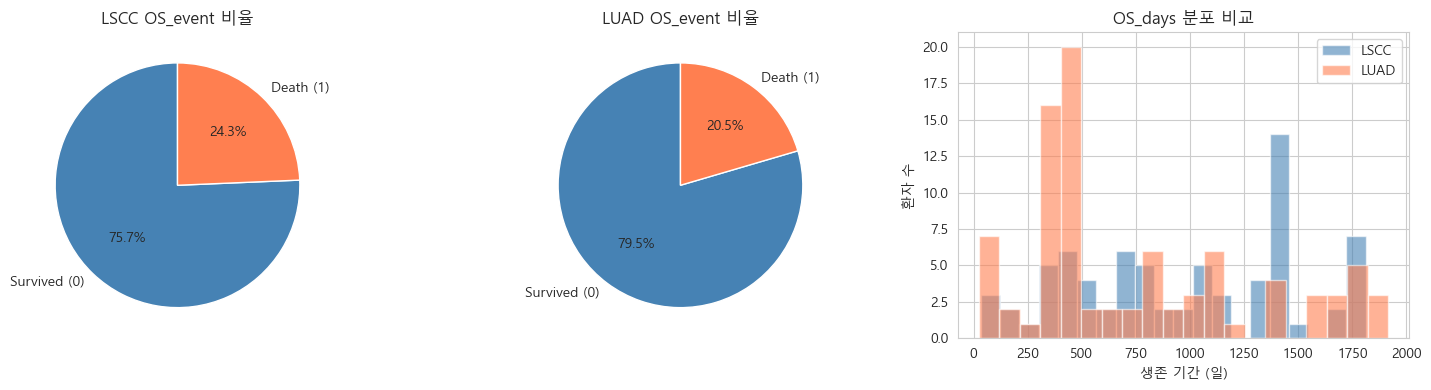

LSCC  중앙값=984일  최소=33일  최대=1812일
LUAD  중앙값=448일  최소=23일  최대=1916일


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes[:2], [("LSCC", lscc_surv), ("LUAD", luad_surv)]):
    counts = [int((df.OS_event == 0).sum()), int(df.OS_event.sum())]
    ax.pie(counts, labels=['Survived (0)', 'Death (1)'],
           autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=90)
    ax.set_title(f'{name} OS_event 비율')

axes[2].hist(lscc_surv.OS_days, bins=20, alpha=0.6, label='LSCC', color='steelblue')
axes[2].hist(luad_surv.OS_days, bins=20, alpha=0.6, label='LUAD', color='coral')
axes[2].set_xlabel('생존 기간 (일)')
axes[2].set_ylabel('환자 수')
axes[2].set_title('OS_days 분포 비교')
axes[2].legend()

plt.tight_layout()
plt.show()

for name, df in [("LSCC", lscc_surv), ("LUAD", luad_surv)]:
    print(f"{name}  중앙값={df.OS_days.median():.0f}일  "
          f"최소={df.OS_days.min()}일  최대={df.OS_days.max()}일")

## 7. Kaplan-Meier 생존 곡선

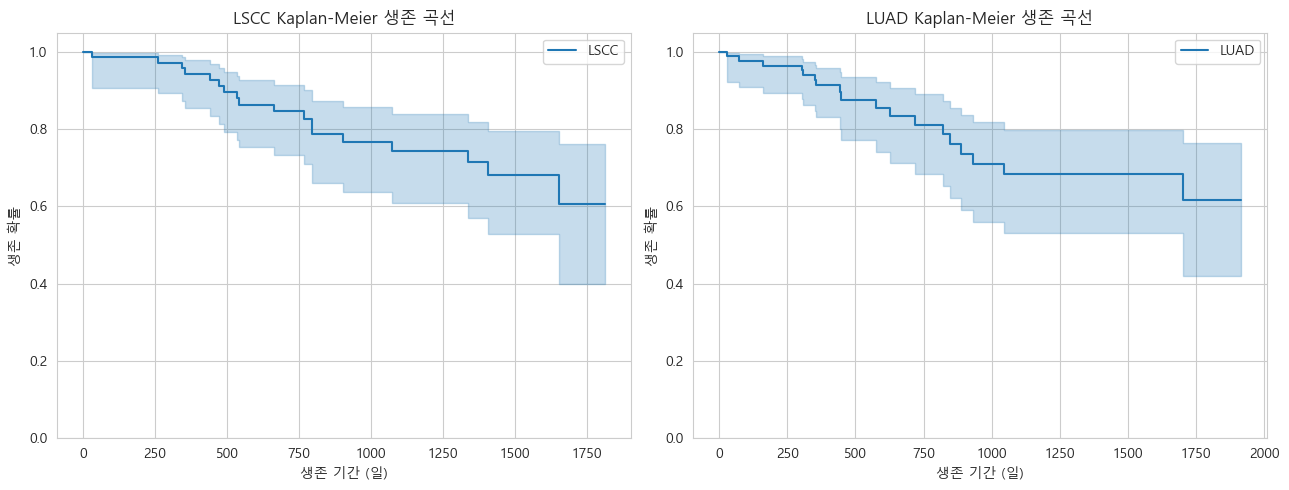

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, surv) in zip(axes, [("LSCC", lscc_surv), ("LUAD", luad_surv)]):
    kmf = KaplanMeierFitter()
    kmf.fit(surv.OS_days, surv.OS_event, label=name)
    kmf.plot_survival_function(ax=ax, ci_show=True)
    ax.set_xlabel('생존 기간 (일)')
    ax.set_ylabel('생존 확률')
    ax.set_title(f'{name} Kaplan-Meier 생존 곡선')
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 8. PCA — 태스크별 분리 확인

In [9]:
def plot_pca(dfs, y, label_names, title, colors=None):
    X = pd.concat(dfs)
    X_imp = SimpleImputer(strategy='median').fit_transform(X)
    X_sc  = StandardScaler().fit_transform(X_imp)
    pcs   = PCA(n_components=2, random_state=42).fit_transform(X_sc)
    if colors is None:
        colors = ['steelblue', 'coral']
    fig, ax = plt.subplots(figsize=(7, 5))
    for i, name in enumerate(label_names):
        mask = np.array(y) == i
        ax.scatter(pcs[mask, 0], pcs[mask, 1],
                   label=name, alpha=0.7, s=40, color=colors[i])
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

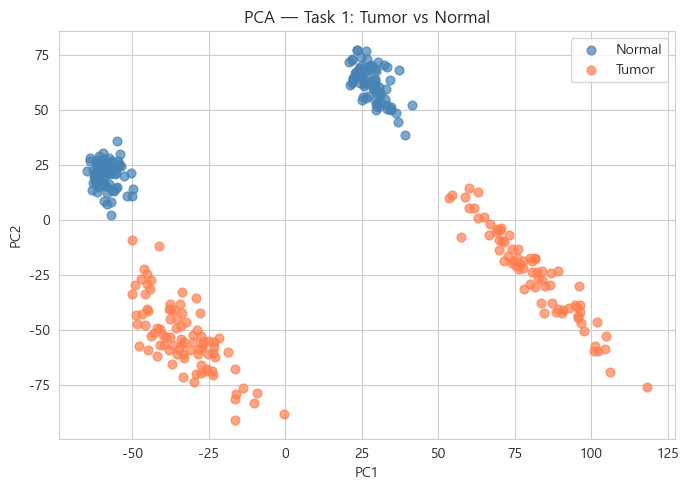

In [10]:
# Task 1: Tumor vs Normal
common_t1 = (lscc_tumor_prot.columns
             .intersection(lscc_nat_prot.columns)
             .intersection(luad_tumor_prot.columns)
             .intersection(luad_nat_prot.columns))

plot_pca(
    [lscc_tumor_prot[common_t1], lscc_nat_prot[common_t1],
     luad_tumor_prot[common_t1], luad_nat_prot[common_t1]],
    [1]*len(lscc_tumor_prot) + [0]*len(lscc_nat_prot) +
    [1]*len(luad_tumor_prot) + [0]*len(luad_nat_prot),
    ['Normal', 'Tumor'],
    'PCA — Task 1: Tumor vs Normal'
)

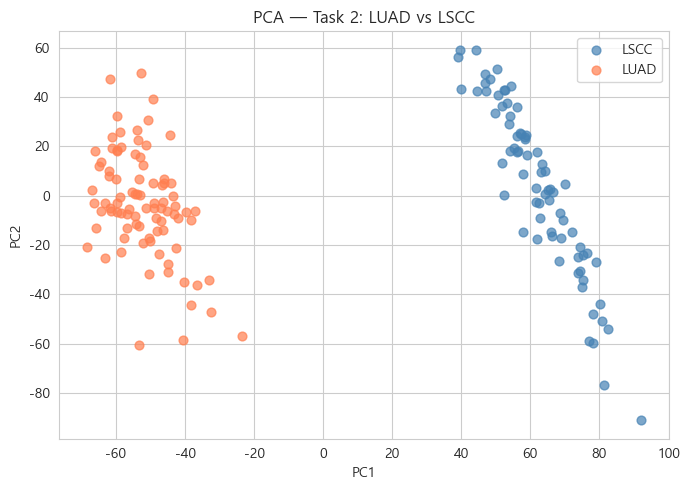

In [11]:
# Task 2: LUAD vs LSCC
common_t2 = lscc_tumor_prot.columns.intersection(luad_tumor_prot.columns)

plot_pca(
    [lscc_tumor_prot[common_t2], luad_tumor_prot[common_t2]],
    [0]*len(lscc_tumor_prot) + [1]*len(luad_tumor_prot),
    ['LSCC', 'LUAD'],
    'PCA — Task 2: LUAD vs LSCC'
)

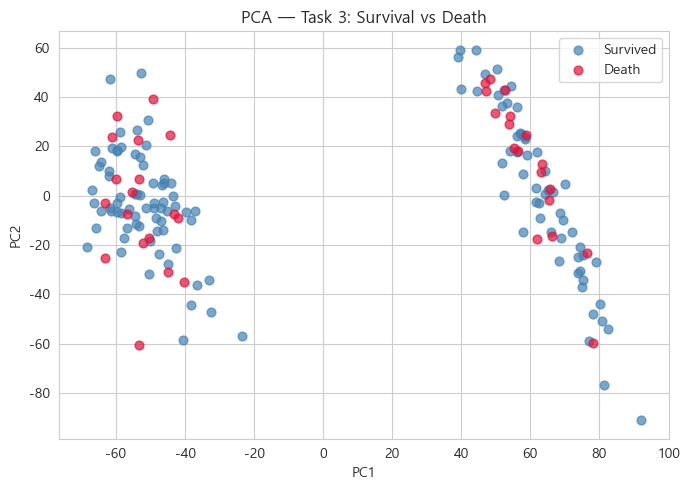

In [12]:
# Task 3: Survival
lscc_ids = lscc_tumor_prot.index.intersection(lscc_surv.index)
luad_ids = luad_tumor_prot.index.intersection(luad_surv.index)

y_surv = np.concatenate([
    lscc_surv.loc[lscc_ids, 'OS_event'].values,
    luad_surv.loc[luad_ids, 'OS_event'].values,
])

plot_pca(
    [lscc_tumor_prot.loc[lscc_ids, common_t2],
     luad_tumor_prot.loc[luad_ids, common_t2]],
    y_surv.tolist(),
    ['Survived', 'Death'],
    'PCA — Task 3: Survival vs Death',
    colors=['steelblue', 'crimson']
)

## 9. 변동성 높은 유전자 TOP 20

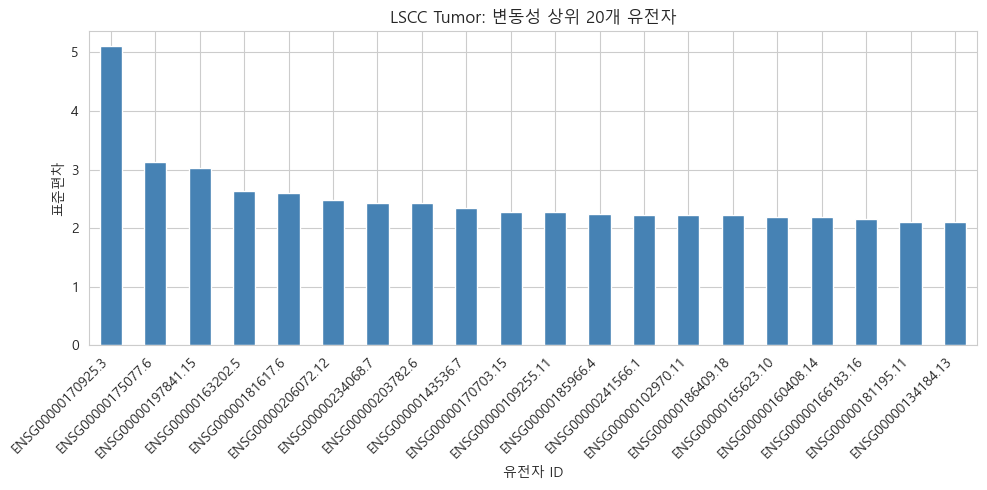

변동성 상위 5개:
idx
ENSG00000170925.3     5.101639
ENSG00000175077.6     3.130029
ENSG00000197841.15    3.022061
ENSG00000163202.5     2.636159
ENSG00000181617.6     2.598732


In [13]:
gene_std = lscc_tumor_prot.std().sort_values(ascending=False)
top20 = gene_std.head(20)

plt.figure(figsize=(10, 5))
top20.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('LSCC Tumor: 변동성 상위 20개 유전자')
plt.xlabel('유전자 ID')
plt.ylabel('표준편차')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("변동성 상위 5개:")
print(top20.head().to_string())